# Slot Scoring Model — learning what each batting-order position "looks like"

**Goal of this notebook:** learn the skill profile of each batting slot (1–9) from recent MLB data, visualize the patterns per slot, and end with the **actual scoring model** our IDSS will use:

```
score(player, slot) = w_trad   x TradFit(player, slot)     <- similarity to the slot's learned profile
                    + w_power  x Power(player, slot)       <- rewards power where slots demand power
                    + w_speed  x Speed(player, slot)       <- rewards speed where slots demand speed
                    + w_offense x Offense(player, slot)    <- front-loads plate appearances to best hitters
```

- The **weights** are the user's sliders (presets like *Aggressive*, *Balanced*, *Small-ball* are saved weight vectors).
- The blended 9x9 matrix goes to the **Hungarian solver** (`linear_sum_assignment`), which also supports **locking** a player into a slot.
- Training window: **2021–2025** (the 5 most recent seasons — our era experiment in `batting_order_models.ipynb` showed recent-era profiles beat 20-year averages).

Sections: (1) data prep → (2) per-slot visual patterns → (3) learn prototypes → (4) build the scoring model → (5) presets, locks, slider-sweep demos → (6) export parameters for the backend.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import linear_sum_assignment

plt.rcParams["figure.facecolor"] = "white"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

ERA_START, ERA_END = 2021, 2025
FEATURES = ["obp", "slg", "iso", "bb_rate", "k_rate", "sb_pg"]
LABELS = {
    "obp": "OBP (on-base)", "slg": "SLG (slugging)", "iso": "ISO (raw power)",
    "bb_rate": "BB% (walks)", "k_rate": "K% (strikeouts)", "sb_pg": "SB/game (speed)",
}

USECOLS = [
    "gid", "id", "team", "b_lp", "b_seq", "gametype", "date",
    "b_pa", "b_ab", "b_h", "b_d", "b_t", "b_hr",
    "b_sf", "b_hbp", "b_w", "b_k", "b_sb",
]
df = pd.read_csv("batting.csv", usecols=USECOLS, low_memory=False)
df["year"] = df["date"] // 10000
starters = df[
    (df["gametype"] == "regular") & (df["b_seq"] == 1)
    & (df["b_lp"].between(1, 9)) & (df["year"] >= 2000)
].copy()
stat_cols = ["b_pa", "b_ab", "b_h", "b_d", "b_t", "b_hr", "b_sf", "b_hbp", "b_w", "b_k", "b_sb"]
starters[stat_cols] = starters[stat_cols].fillna(0)


def player_season_features(st):
    a = (
        st.groupby(["id", "year"])
        .agg(games=("gid", "nunique"), pa=("b_pa", "sum"), ab=("b_ab", "sum"),
             h=("b_h", "sum"), d2=("b_d", "sum"), t3=("b_t", "sum"), hr=("b_hr", "sum"),
             sf=("b_sf", "sum"), hbp=("b_hbp", "sum"), bb=("b_w", "sum"),
             k=("b_k", "sum"), sb=("b_sb", "sum"))
        .reset_index()
    )
    a = a[(a["pa"] >= 150) & (a["ab"] > 0)].copy()
    singles = (a["h"] - a["d2"] - a["t3"] - a["hr"]).clip(lower=0)
    tb = singles + 2 * a["d2"] + 3 * a["t3"] + 4 * a["hr"]
    a["obp"] = (a["h"] + a["bb"] + a["hbp"]) / (a["ab"] + a["bb"] + a["hbp"] + a["sf"])
    a["slg"] = tb / a["ab"]
    a["ops"] = a["obp"] + a["slg"]
    a["iso"] = a["slg"] - a["h"] / a["ab"]
    a["bb_rate"] = a["bb"] / a["pa"]
    a["k_rate"] = a["k"] / a["pa"]
    a["sb_pg"] = a["sb"] / a["games"]
    return a


agg = player_season_features(starters)

slot_counts = starters.groupby(["id", "year", "b_lp"]).size().rename("n").reset_index()
primary = slot_counts.loc[slot_counts.groupby(["id", "year"])["n"].idxmax()].copy()
primary["starts"] = slot_counts.groupby(["id", "year"])["n"].sum().values
primary["slot_share"] = primary["n"] / primary["starts"]

# Training set: recent-era regulars with a stable slot
regulars = primary[
    primary["year"].between(ERA_START, ERA_END)
    & (primary["starts"] >= 80) & (primary["slot_share"] >= 0.5)
][["id", "year", "b_lp"]].merge(agg, on=["id", "year"]).rename(columns={"b_lp": "slot"})

print(f"Recent-era ({ERA_START}-{ERA_END}) regulars with stable slots: {len(regulars):,}")
regulars.groupby("slot").size()

Recent-era (2021-2025) regulars with stable slots: 517


slot
1.0    135
2.0    115
3.0     90
4.0     75
5.0     14
6.0      5
7.0      4
8.0     18
9.0     61
dtype: int64

## 1. What does each slot look like? (visual patterns)

Four views of the same question:
1. **Bar charts** — average of each skill by slot.
2. **Radar "fingerprints"** — one polar chart per slot showing its full profile at a glance.
3. **Distributions** — OPS violins per slot (how much slots overlap).
4. **Era drift** — how the #2 vs #3 slot swapped roles over 25 years (why we train on recent seasons only).

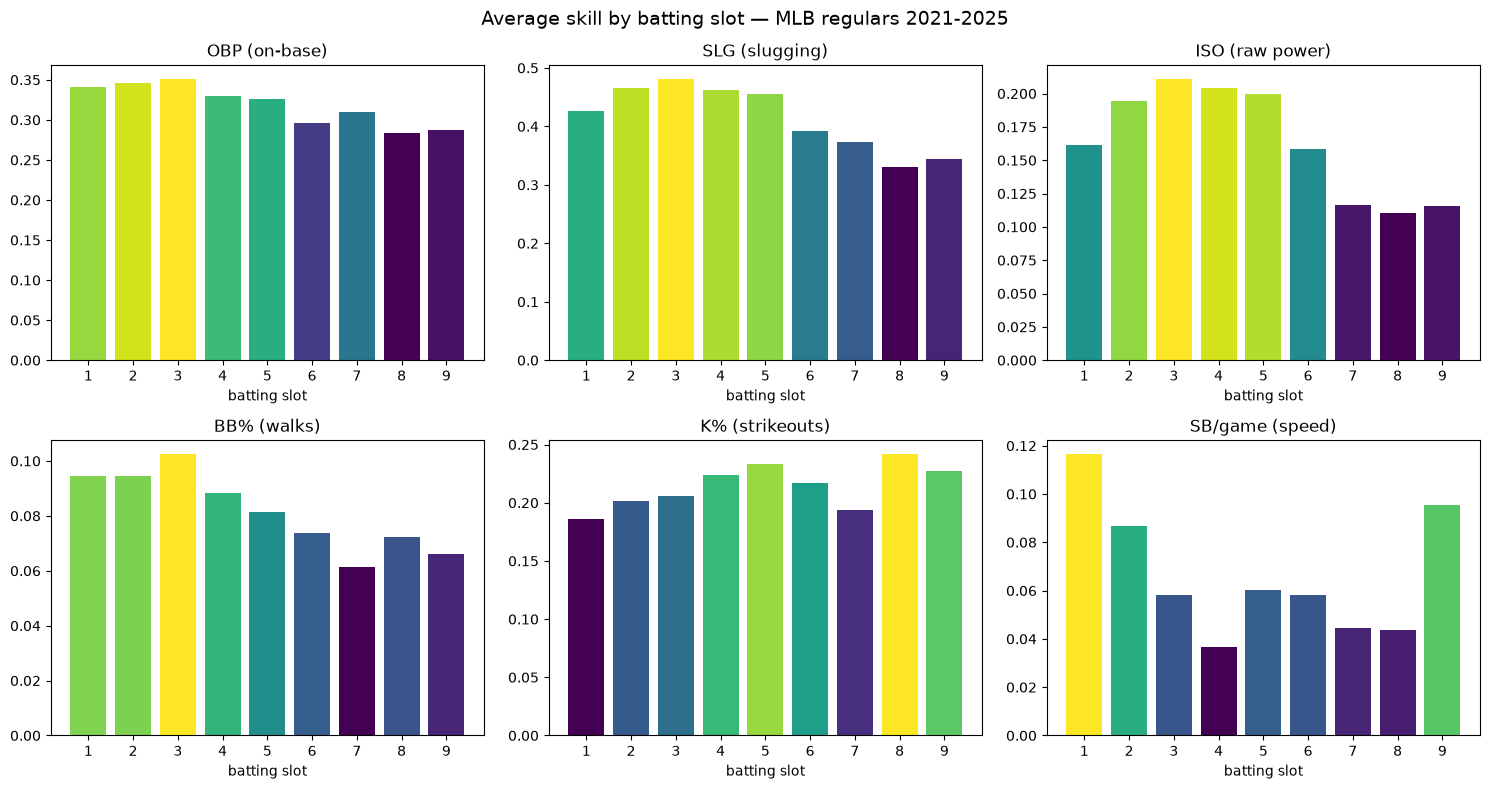

In [2]:
# 1a. Average skill by slot
slot_means = regulars.groupby("slot")[FEATURES].mean()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, FEATURES):
    vals = slot_means[feat]
    colors = plt.cm.viridis((vals - vals.min()) / (vals.max() - vals.min() + 1e-12))
    ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(LABELS[feat])
    ax.set_xticks(range(1, 10))
    ax.set_xlabel("batting slot")
fig.suptitle(f"Average skill by batting slot — MLB regulars {ERA_START}-{ERA_END}", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "recent_slot_profiles.png", dpi=110, bbox_inches="tight")
plt.show()

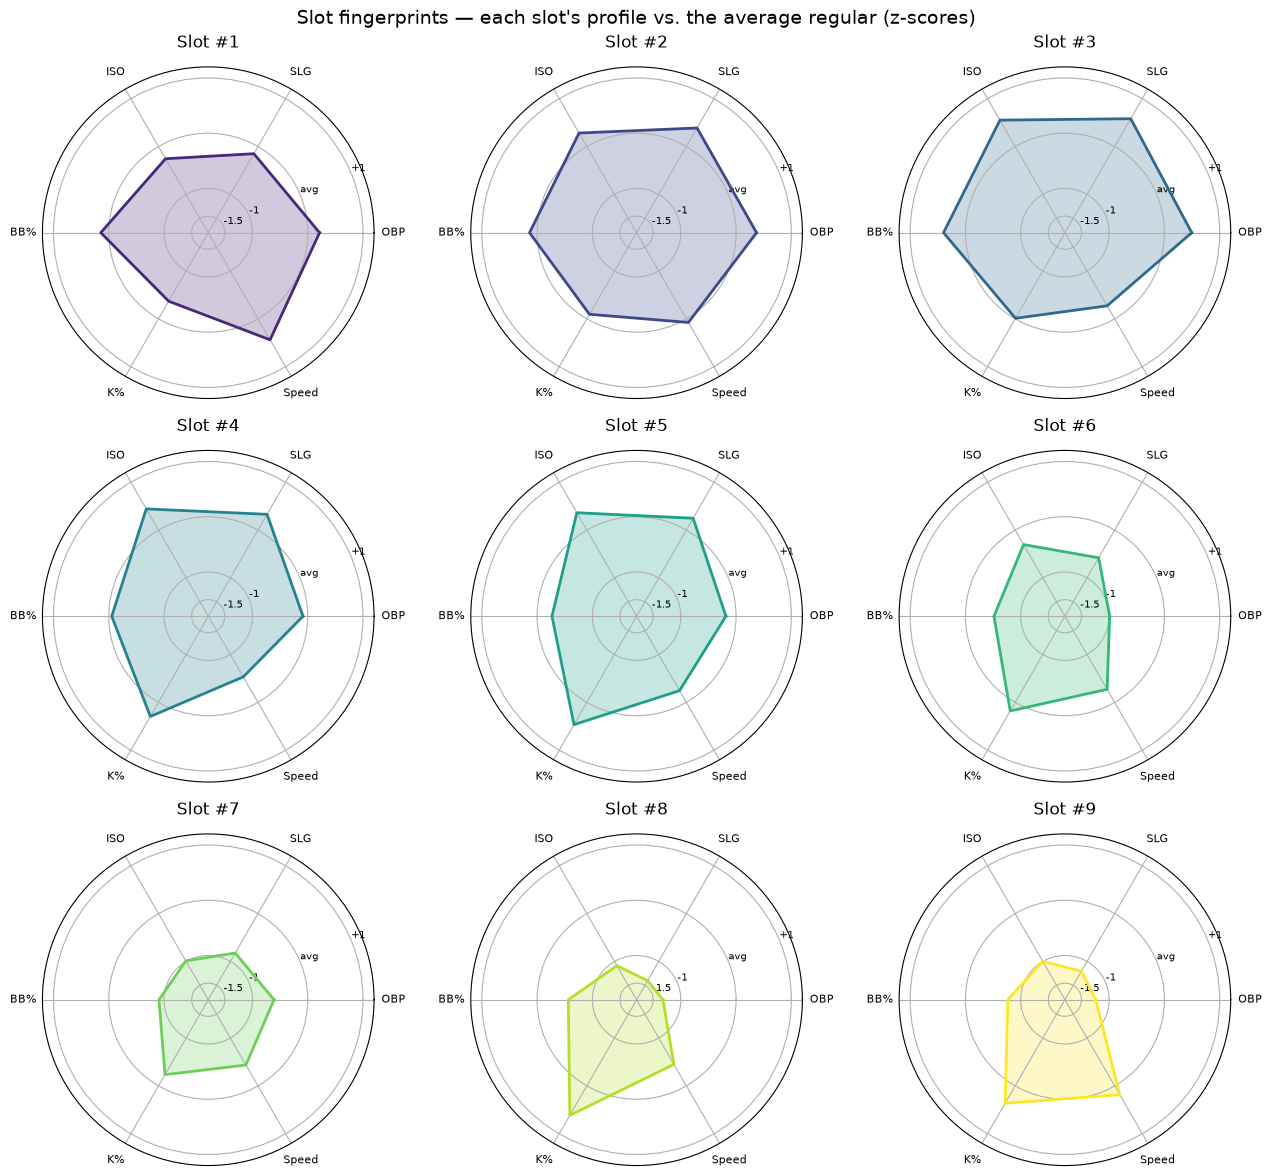

In [3]:
# 1b. Radar fingerprint per slot (z-scored so all skills share a scale)
z_all = (regulars[FEATURES] - regulars[FEATURES].mean()) / regulars[FEATURES].std()
z_all["slot"] = regulars["slot"].values
slot_z = z_all.groupby("slot").mean()

angles = np.linspace(0, 2 * np.pi, len(FEATURES), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(3, 3, figsize=(13, 12), subplot_kw={"polar": True})
for ax, s in zip(axes.flat, range(1, 10)):
    vals = slot_z.loc[s].tolist() + [slot_z.loc[s].iloc[0]]
    ax.plot(angles, vals, color=plt.cm.viridis(s / 9), lw=2)
    ax.fill(angles, vals, color=plt.cm.viridis(s / 9), alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(["OBP", "SLG", "ISO", "BB%", "K%", "Speed"], fontsize=8)
    ax.set_ylim(-1.8, 1.2)  # floor below the most negative prototype value so nothing clips
    ax.set_yticks([-1.5, -1, 0, 1])
    ax.set_yticklabels(["-1.5", "-1", "avg", "+1"], fontsize=7)
    ax.set_title(f"Slot #{s}", fontsize=12, pad=14)
fig.suptitle("Slot fingerprints — each slot's profile vs. the average regular (z-scores)", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "slot_radars.png", dpi=110, bbox_inches="tight")
plt.show()

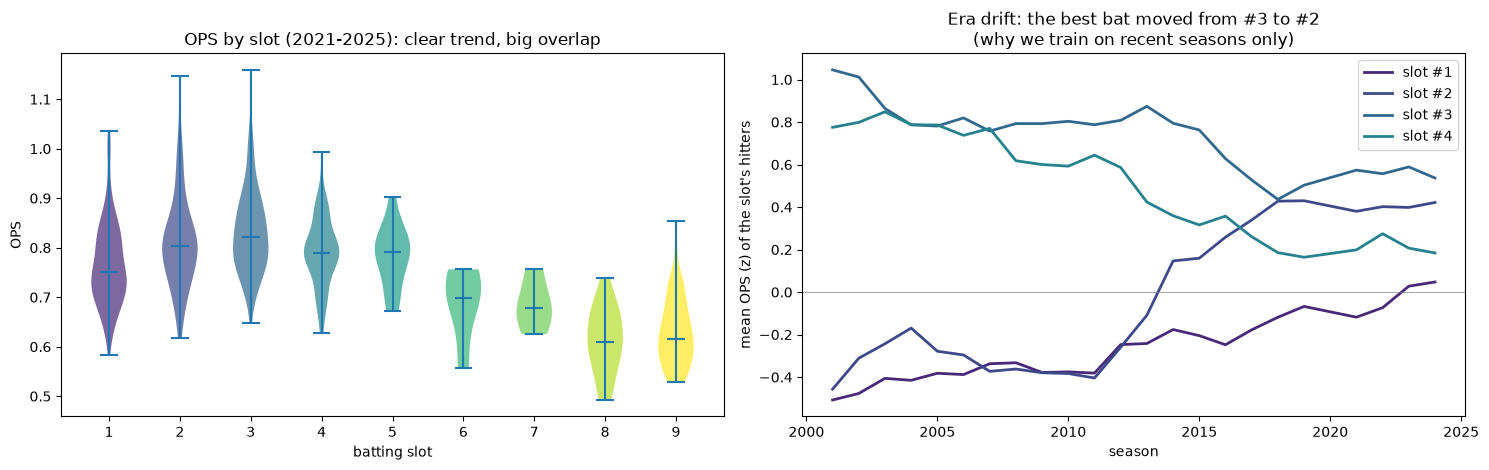

In [4]:
# 1c. OPS distribution per slot + 1d. era drift of the "best hitter" slot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.8))

data = [regulars.loc[regulars["slot"] == s, "ops"].values for s in range(1, 10)]
parts = ax1.violinplot(data, positions=range(1, 10), showmedians=True)
for pc, s in zip(parts["bodies"], range(1, 10)):
    pc.set_facecolor(plt.cm.viridis(s / 9))
    pc.set_alpha(0.7)
ax1.set_xticks(range(1, 10))
ax1.set_xlabel("batting slot")
ax1.set_ylabel("OPS")
ax1.set_title(f"OPS by slot ({ERA_START}-{ERA_END}): clear trend, big overlap")

# Era drift: where do the best hitters bat over time? Mean OPS z-score per slot per year.
hist = primary[(primary["starts"] >= 80) & (primary["slot_share"] >= 0.5)][
    ["id", "year", "b_lp"]].merge(agg, on=["id", "year"])
hist["ops_z"] = hist.groupby("year")["ops"].transform(lambda x: (x - x.mean()) / x.std())
drift = hist.groupby(["year", "b_lp"])["ops_z"].mean().unstack()
for s in [1, 2, 3, 4]:
    ax2.plot(drift.index, drift[s].rolling(3, center=True).mean(),
             label=f"slot #{s}", color=plt.cm.viridis(s / 9), lw=2)
ax2.axhline(0, color="grey", lw=0.5)
ax2.set_xlabel("season")
ax2.set_ylabel("mean OPS (z) of the slot's hitters")
ax2.set_title("Era drift: the best bat moved from #3 to #2\n(why we train on recent seasons only)")
ax2.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "slot_distributions_drift.png", dpi=110, bbox_inches="tight")
plt.show()

## 2. Learn the model's parameters

Three sets of numbers come out of the data — together they're the entire "learned" part of the model:

1. **Scaler** (mean/std per skill) — puts any player's stats into z-score space.
2. **Prototypes** — the 9 slot fingerprints above, as a 9x6 matrix. `TradFit` = closeness to these.
3. **Slot demand vectors** — how much each slot "wants" power / speed / plate appearances:
   - power & speed demand come from the prototypes' ISO and SB columns,
   - PA share per slot comes straight from game data (slot 1 bats ~11% more often than slot 9).

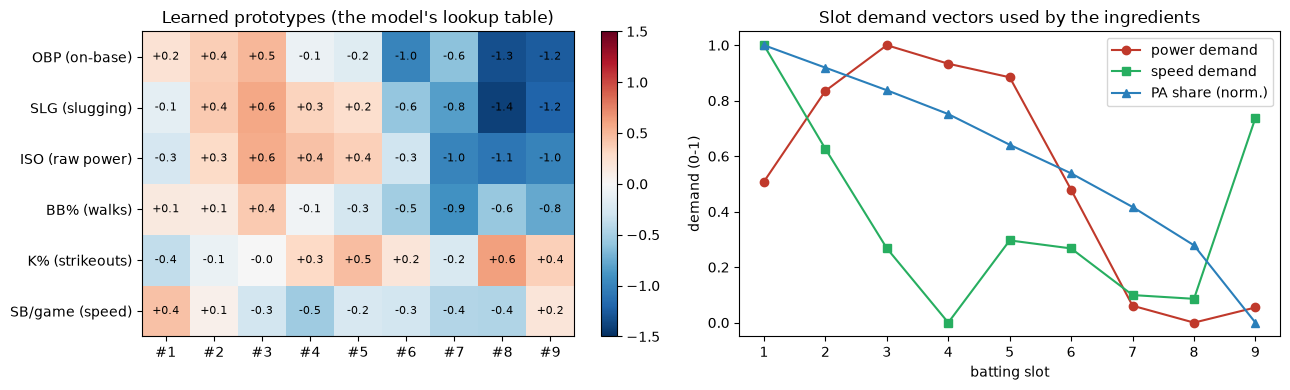

PA/game by slot: [8.98 8.78 8.59 8.38 8.12 7.87 7.59 7.26 6.59]


In [5]:
def minmax(v):
    v = np.asarray(v, dtype=float)
    return (v - v.min()) / (v.max() - v.min() + 1e-12)


# (1) scaler and (2) prototypes
FEAT_MEAN = regulars[FEATURES].mean()
FEAT_STD = regulars[FEATURES].std()
PROTOTYPES = slot_z.values  # (9 slots, 6 features), z-space

# (3) slot demand vectors
POWER_DEMAND = minmax(PROTOTYPES[:, FEATURES.index("iso")])
SPEED_DEMAND = minmax(PROTOTYPES[:, FEATURES.index("sb_pg")])

recent_starters = starters[starters["year"].between(ERA_START, ERA_END)]
pa_per_game = recent_starters.groupby("b_lp")["b_pa"].sum() / recent_starters["gid"].nunique()
PA_SHARE = (pa_per_game / pa_per_game.sum()).values
PA_DEMAND = minmax(PA_SHARE)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
im = ax1.imshow(PROTOTYPES.T, cmap="RdBu_r", vmin=-1.5, vmax=1.5, aspect="auto")
ax1.set_xticks(range(9), labels=[f"#{s}" for s in range(1, 10)])
ax1.set_yticks(range(6), labels=[LABELS[f] for f in FEATURES])
for i in range(6):
    for j in range(9):
        ax1.text(j, i, f"{PROTOTYPES[j, i]:+.1f}", ha="center", va="center", fontsize=8)
ax1.set_title("Learned prototypes (the model's lookup table)")
fig.colorbar(im, ax=ax1)

x = np.arange(1, 10)
ax2.plot(x, POWER_DEMAND, "o-", label="power demand", color="#c0392b")
ax2.plot(x, SPEED_DEMAND, "s-", label="speed demand", color="#27ae60")
ax2.plot(x, PA_DEMAND, "^-", label="PA share (norm.)", color="#2a7fba")
ax2.set_xticks(x)
ax2.set_xlabel("batting slot")
ax2.set_ylabel("demand (0-1)")
ax2.set_title("Slot demand vectors used by the ingredients")
ax2.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "learned_parameters.png", dpi=110, bbox_inches="tight")
plt.show()

print("PA/game by slot:", np.round(pa_per_game.values, 2))

## 3. The scoring model

Each ingredient produces its own 9x9 matrix (players x slots), normalized to 0–1 so slider weights compare like-for-like:

- **TradFit** — negative distance between the player's z-profile and each slot prototype.
- **Power** — `player_power x slot_power_demand` (outer product): strong hitters score high exactly in the slots that historically hold power.
- **Speed** — same construction with speed.
- **Offense** — `player_overall_quality x slot_PA_share`: rewards giving your best hitters the most plate appearances (this is the "greedy" logic as a soft ingredient).

`recommend_order(players, weights, locks)` blends the matrices with the user's weights and solves the assignment. **Locks** are enforced by making the locked pair irresistible to the solver (and that slot prohibitively expensive for everyone else), so the remaining 8 players are re-optimized around the coach's choice — the human-in-the-loop mechanic.

In [6]:
def ingredient_matrices(players):
    """players: DataFrame with FEATURES columns (any 9 players).
    Returns dict of 9x9 matrices (rows=players, cols=slots 1-9), each in 0-1."""
    Z = ((players[FEATURES] - FEAT_MEAN) / FEAT_STD).values

    dist = np.sqrt(((Z[:, None, :] - PROTOTYPES[None, :, :]) ** 2).sum(axis=2))
    trad = minmax(-dist)

    power = np.outer(minmax(Z[:, FEATURES.index("iso")]), POWER_DEMAND)
    speed = np.outer(minmax(Z[:, FEATURES.index("sb_pg")]), SPEED_DEMAND)

    quality = minmax(Z[:, FEATURES.index("obp")] + Z[:, FEATURES.index("slg")])
    offense = np.outer(quality, PA_DEMAND)

    return {"trad": trad, "power": power, "speed": speed, "offense": offense}


PRESETS = {
    "Balanced":    {"trad": 1.0, "power": 0.0, "speed": 0.0, "offense": 0.3},
    "Aggressive":  {"trad": 0.3, "power": 1.0, "speed": 0.0, "offense": 0.7},
    "Small-ball":  {"trad": 0.4, "power": 0.0, "speed": 1.0, "offense": 0.3},
    "Max offense": {"trad": 0.0, "power": 0.0, "speed": 0.0, "offense": 1.0},
}

LOCK_BONUS = 1e6


def recommend_order(players, weights, locks=None):
    """players: DataFrame of 9 players. weights: dict over ingredients.
    locks: {player_row_index: slot(1-9)}. Returns (slots array, blended matrix)."""
    mats = ingredient_matrices(players)
    M = sum(w * mats[k] for k, w in weights.items())

    if locks:
        for p_idx, slot in locks.items():
            col = slot - 1
            M[p_idx, :] -= LOCK_BONUS      # this player: nothing else is acceptable
            M[:, col] -= LOCK_BONUS        # this slot: nobody else is acceptable
            M[p_idx, col] += 3 * LOCK_BONUS  # ...except this exact pairing

    rows, cols = linear_sum_assignment(-M)  # maximize total score
    slots = np.zeros(len(players), dtype=int)
    slots[rows] = cols + 1
    return slots, M


def show_lineups(players, configs, locks_by_name=None):
    """Side-by-side table: one column per configuration."""
    out = pd.DataFrame(index=range(1, 10))
    for name, weights in configs.items():
        locks = (locks_by_name or {}).get(name)
        slots, _ = recommend_order(players, weights, locks)
        col = [None] * 9
        for i, s in enumerate(slots):
            tag = players["name"].iloc[i] if "name" in players else players["id"].iloc[i]
            col[s - 1] = tag + (" *LOCK*" if locks and locks.get(i) == s else "")
        out[name] = col
    out.index.name = "slot"
    return out

print("scoring model ready")

scoring model ready


## 4. Demo on a real roster

We grab one 2025 team's nine most-used starters and run the model. Three demos:

1. **Presets side by side** — the same 9 players, four strategies, four different orders (the "scenario comparison" feature).
2. **Locking** — the coach pins a player to a slot; the model re-optimizes everyone else around it.
3. **Slider sweep** — drag the aggression slider from 0 to 1 and watch each player's slot move (this is what the UI slider will do live).

In [7]:
# Build a demo roster: one 2025 team's typical nine
yr = ERA_END
st_demo = starters[starters["year"] == yr]
tc = st_demo.groupby(["team", "b_lp", "id"]).size().rename("n").reset_index()
top = tc.loc[tc.groupby(["team", "b_lp"])["n"].idxmax()]

demo = None
for team, grp in top.groupby("team"):
    if len(grp) == 9 and grp["id"].nunique() == 9:
        keys = [(pid, yr) for pid in grp["id"]]
        pool = agg.set_index(["id", "year"])
        if all(k in pool.index for k in keys):
            demo = pool.loc[keys].reset_index()
            demo["true_slot"] = grp["b_lp"].values.astype(int)
            demo["team"] = team
            break

demo["name"] = demo["id"]
print(f"Demo roster: {demo['team'].iloc[0]} {yr}")
demo[["name", "true_slot", "obp", "slg", "iso", "sb_pg", "ops"]].round(3)

Demo roster: DET 2025


,name,true_slot,obp,slg,iso,sb_pg,ops
0,keitc001,1,0.334,0.416,0.157,0.009,0.751
1,torrg001,2,0.358,0.389,0.132,0.028,0.747
2,carpk001,3,0.296,0.501,0.244,0.009,0.797
3,greer003,4,0.315,0.498,0.237,0.013,0.813
4,torks001,5,0.333,0.457,0.217,0.013,0.791
5,perew002,6,0.313,0.438,0.189,0.086,0.751
6,dingd001,7,0.328,0.428,0.151,0.000,0.756
7,sweet001,8,0.262,0.311,0.106,0.037,0.573
8,baezj001,9,0.286,0.407,0.145,0.043,0.693


In [8]:
# Demo 1: four presets, side by side (+ the real manager's order for reference)
table = show_lineups(demo, PRESETS)
table.insert(0, "Manager (actual)",
             [demo.loc[demo["true_slot"] == s, "name"].iloc[0] for s in range(1, 10)])
table

,Manager (actual),Balanced,Aggressive,Small-ball,Max offense
slot,,,,,
1,keitc001,torrg001,torrg001,perew002,greer003
2,torrg001,keitc001,torks001,torrg001,torks001
3,carpk001,torks001,greer003,torks001,torrg001
4,greer003,greer003,carpk001,keitc001,carpk001
5,torks001,perew002,perew002,greer003,keitc001
6,perew002,carpk001,keitc001,carpk001,dingd001
7,dingd001,dingd001,dingd001,dingd001,perew002
8,sweet001,sweet001,baezj001,sweet001,baezj001
9,baezj001,baezj001,sweet001,baezj001,sweet001


In [9]:
# Demo 2: lock a player and re-optimize the rest.
# Take the Balanced lineup's cleanup hitter and lock him into the leadoff spot instead.
base_slots, base_M = recommend_order(demo, PRESETS["Balanced"])
cleanup_idx = int(np.where(base_slots == 4)[0][0])
locked_slots, _ = recommend_order(demo, PRESETS["Balanced"], locks={cleanup_idx: 1})

cmp = pd.DataFrame(index=range(1, 10))
cmp["Balanced"] = [demo["name"].iloc[np.where(base_slots == s)[0][0]] for s in range(1, 10)]
cmp[f"Balanced + LOCK {demo['name'].iloc[cleanup_idx]} -> #1"] = [
    demo["name"].iloc[np.where(locked_slots == s)[0][0]] for s in range(1, 10)]
cmp.index.name = "slot"
print(f"Locked player: {demo['name'].iloc[cleanup_idx]} (was #4, forced to #1)")
cmp

Locked player: greer003 (was #4, forced to #1)


,Balanced,Balanced + LOCK greer003 -> #1
slot,,
1,torrg001,greer003
2,keitc001,torrg001
3,torks001,torks001
4,greer003,keitc001
5,perew002,perew002
6,carpk001,carpk001
7,dingd001,dingd001
8,sweet001,sweet001
9,baezj001,baezj001


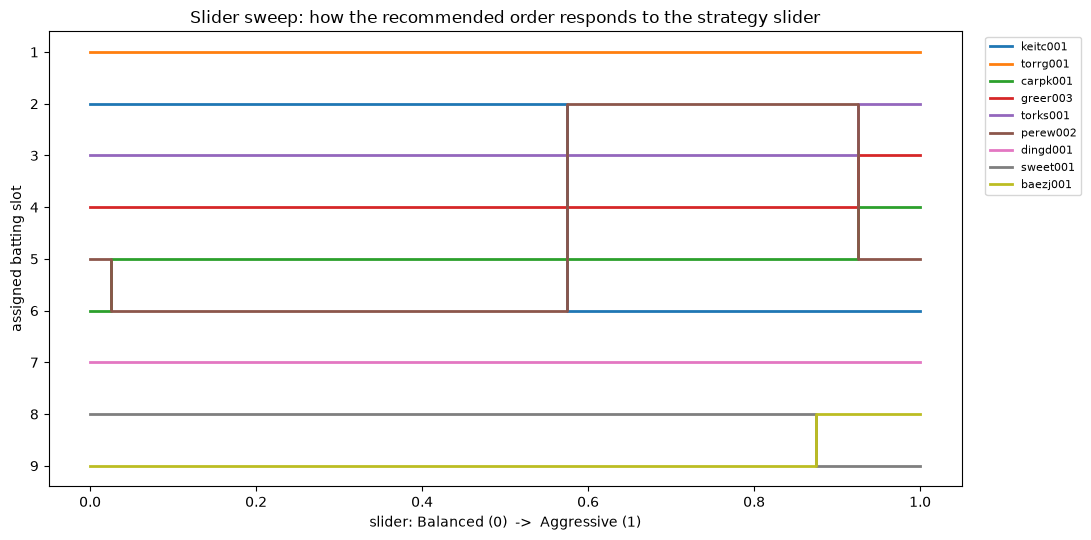

Order changes 4 times across 21 slider steps (smooth, not chaotic).


In [10]:
# Demo 3: slider sweep — Balanced -> Aggressive, watch each player's slot move
sweep = np.linspace(0, 1, 21)
traj = np.zeros((len(demo), len(sweep)), dtype=int)
for j, t in enumerate(sweep):
    w = {k: (1 - t) * PRESETS["Balanced"][k] + t * PRESETS["Aggressive"][k]
         for k in PRESETS["Balanced"]}
    traj[:, j], _ = recommend_order(demo, w)

fig, ax = plt.subplots(figsize=(11, 5.5))
for i in range(len(demo)):
    ax.plot(sweep, traj[i], drawstyle="steps-mid", lw=2,
            color=plt.cm.tab10(i % 10), label=demo["name"].iloc[i])
ax.invert_yaxis()
ax.set_yticks(range(1, 10))
ax.set_xlabel('slider: Balanced (0)  ->  Aggressive (1)')
ax.set_ylabel("assigned batting slot")
ax.set_title("Slider sweep: how the recommended order responds to the strategy slider")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "slider_sweep.png", dpi=110, bbox_inches="tight")
plt.show()

n_changes = (np.diff(traj, axis=1) != 0).any(axis=0).sum()
print(f"Order changes {n_changes} times across 21 slider steps (smooth, not chaotic).")

## 5. Export the model parameters for the backend

Everything the backend needs to reproduce this model is a small JSON file: the feature list, scaler, prototypes, and demand vectors. `backend/model/batting_order.py` loads it and implements `ingredient_matrices` + `recommend_order` exactly as above — no CSV, no training, no ML runtime.

In [11]:
params = {
    "trained_on": f"MLB regular-season starters {ERA_START}-{ERA_END}",
    "n_player_seasons": int(len(regulars)),
    "features": FEATURES,
    "scaler_mean": FEAT_MEAN.round(6).to_dict(),
    "scaler_std": FEAT_STD.round(6).to_dict(),
    "prototypes": np.round(PROTOTYPES, 4).tolist(),      # 9 slots x 6 features, z-space
    "power_demand": np.round(POWER_DEMAND, 4).tolist(),
    "speed_demand": np.round(SPEED_DEMAND, 4).tolist(),
    "pa_share": np.round(PA_SHARE, 4).tolist(),
    "presets": PRESETS,
}
out_path = Path("../backend/data/processed/slot_scoring.json")
out_path.write_text(json.dumps(params, indent=2))
print(f"Wrote {out_path.resolve()} ({out_path.stat().st_size:,} bytes)")

Wrote /Users/joshkim/Documents/UW-Term-Work/4A/MSE 436/mse436-idss-project/backend/data/processed/slot_scoring.json (2,230 bytes)


## Summary

- Each batting slot has a **distinct, learnable fingerprint** (radars above); the strongest signals are speed at #1, overall quality at #2–#4, power at #3–#5, and weak bats at #8–#9.
- The **scoring model** = four interpretable ingredient matrices blended by user weights, solved with the Hungarian algorithm. Presets, sliders, and locks are all just different inputs to the same function — nothing about the solver changes.
- The slider sweep shows the model responds **smoothly** to weight changes (a handful of clean swaps, not chaos) — important for user trust in the interactive UI.
- All learned parameters ship as `backend/data/processed/slot_scoring.json`; the backend implementation is a direct copy of `ingredient_matrices` + `recommend_order` from this notebook.